In [1]:
# Drug Classification Using Machine Learning
# Dataset: Drug200 | Models: LR, DT, RF, KNN, SVM

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
RANDOM_STATE = 42

In [3]:
## Task 1: Exploratory Data Analysis (EDA)

In [4]:
df = pd.read_csv("drug200.csv")
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [5]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
df.describe()

Shape: (200, 6)

Data Types:
 Age              int64
Sex             object
BP              object
Cholesterol     object
Na_to_K        float64
Drug            object
dtype: object

Missing Values:
 Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64


,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


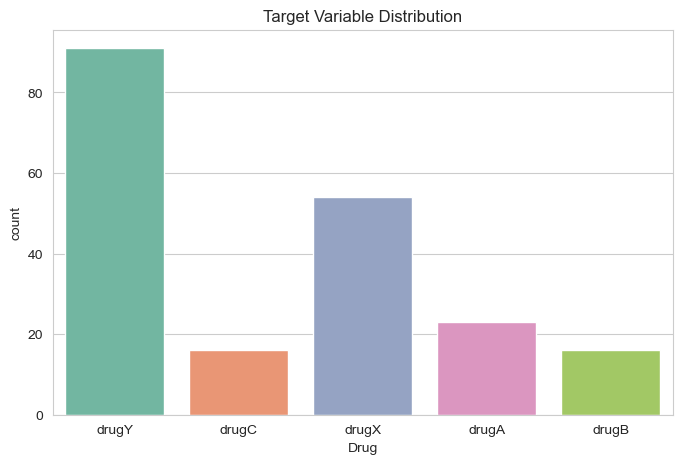

Drug
drugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


In [6]:
plt.figure(figsize=(8,5))
sns.countplot(x="Drug", data=df, palette="Set2")
plt.title("Target Variable Distribution")
plt.show()
print(df["Drug"].value_counts())

In [7]:
## Task 2: Data Preprocessing

In [8]:
le = LabelEncoder()
df_encoded = df.copy()

for col in ["Sex", "BP", "Cholesterol"]:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,drugY
1,47,1,1,0,13.093,drugC
2,47,1,1,0,10.114,drugC
3,28,0,2,0,7.798,drugX
4,61,0,1,0,18.043,drugY


In [9]:
X = df_encoded.drop("Drug", axis=1)
y = df_encoded["Drug"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (200, 5)
Target shape: (200,)


In [10]:
## Task 3: Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (160, 5)
Test size: (40, 5)


In [12]:
## Task 4: Train Classification Models

In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(random_state=RANDOM_STATE)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained ✅")

Logistic Regression trained ✅
Decision Tree trained ✅
Random Forest trained ✅
KNN trained ✅
SVM trained ✅


In [14]:
## Task 5: Model Evaluation


Model: Logistic Regression
Accuracy: 0.9000

Classification Report:
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         6
       drugB       0.75      1.00      0.86         3
       drugC       1.00      0.40      0.57         5
       drugX       0.77      0.91      0.83        11
       drugY       1.00      1.00      1.00        15

    accuracy                           0.90        40
   macro avg       0.90      0.86      0.85        40
weighted avg       0.92      0.90      0.89        40



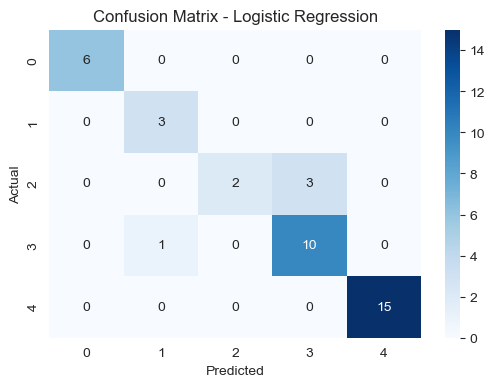


Model: Decision Tree
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         6
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         5
       drugX       1.00      1.00      1.00        11
       drugY       1.00      1.00      1.00        15

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



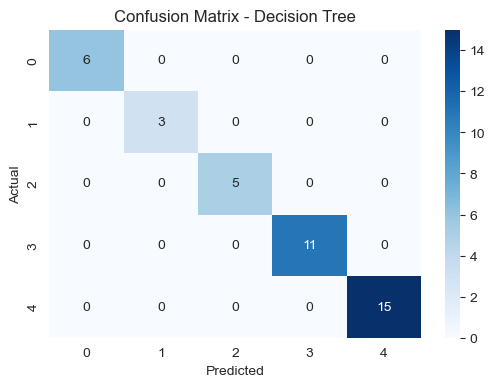


Model: Random Forest
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         6
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         5
       drugX       1.00      1.00      1.00        11
       drugY       1.00      1.00      1.00        15

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



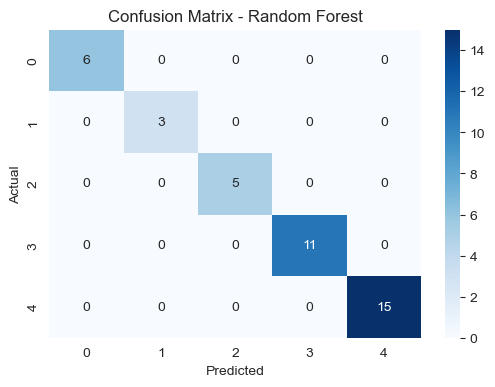


Model: KNN
Accuracy: 0.7000

Classification Report:
              precision    recall  f1-score   support

       drugA       0.60      0.50      0.55         6
       drugB       0.33      0.67      0.44         3
       drugC       1.00      0.20      0.33         5
       drugX       0.54      0.64      0.58        11
       drugY       1.00      1.00      1.00        15

    accuracy                           0.70        40
   macro avg       0.69      0.60      0.58        40
weighted avg       0.76      0.70      0.69        40



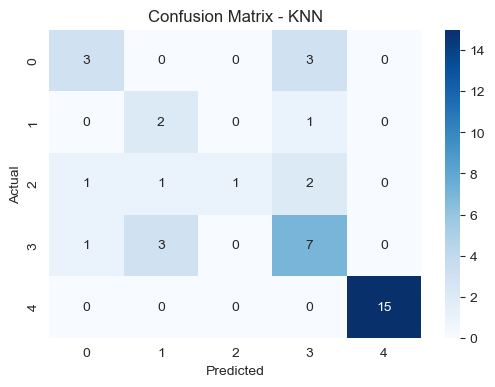


Model: SVM
Accuracy: 0.6250

Classification Report:
              precision    recall  f1-score   support

       drugA       0.00      0.00      0.00         6
       drugB       0.00      0.00      0.00         3
       drugC       0.00      0.00      0.00         5
       drugX       0.43      0.91      0.59        11
       drugY       0.88      1.00      0.94        15

    accuracy                           0.62        40
   macro avg       0.26      0.38      0.31        40
weighted avg       0.45      0.62      0.51        40



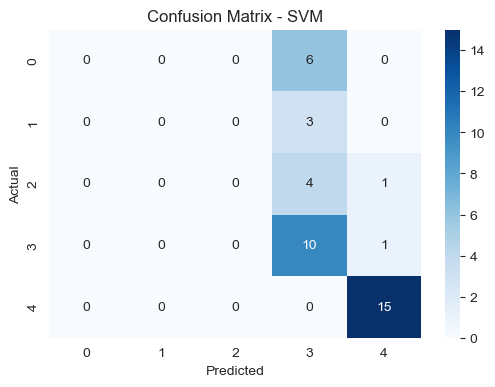

In [15]:
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), 
                annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

In [16]:
## Task 6: Model Comparison

              Model  Accuracy
      Decision Tree     1.000
      Random Forest     1.000
Logistic Regression     0.900
                KNN     0.700
                SVM     0.625


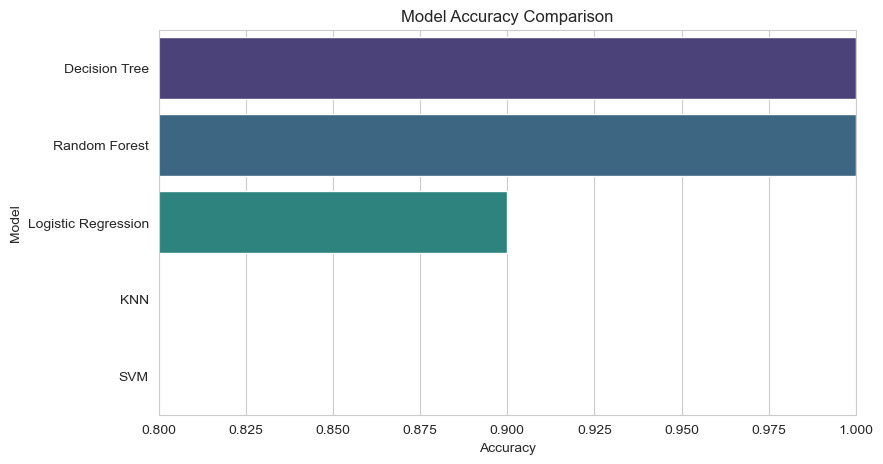


Best Model: Decision Tree


In [17]:
comparison_df = pd.DataFrame(
    list(results.items()), 
    columns=["Model", "Accuracy"]
).sort_values("Accuracy", ascending=False).reset_index(drop=True)

print(comparison_df.to_string(index=False))

plt.figure(figsize=(9,5))
sns.barplot(x="Accuracy", y="Model", data=comparison_df, palette="viridis")
plt.title("Model Accuracy Comparison")
plt.xlim(0.8, 1.0)
plt.show()

best = comparison_df.iloc[0]["Model"]
print(f"\nBest Model: {best}")

In [18]:
## Task 7: Prediction Testing

In [19]:
custom_patients = pd.DataFrame({
    "Age":         [25,  47,  35,  60,  50],
    "Sex":         [1,   0,   1,   0,   1],   # 1=M, 0=F
    "BP":          [2,   0,   1,   2,   0],   # 2=HIGH,1=LOW,0=NORMAL
    "Cholesterol": [1,   0,   1,   0,   1],   # 1=NORMAL, 0=HIGH
    "Na_to_K":     [25.3, 13.1, 10.5, 27.8, 15.2]
})

best_model = models["Random Forest"]
predictions = best_model.predict(custom_patients)

custom_patients["Predicted Drug"] = predictions
print(custom_patients.to_string(index=False))

 Age  Sex  BP  Cholesterol  Na_to_K Predicted Drug
  25    1   2            1     25.3          drugY
  47    0   0            0     13.1          drugA
  35    1   1            1     10.5          drugX
  60    0   2            0     27.8          drugY
  50    1   0            1     15.2          drugY


In [20]:
## Bonus: ML Pipeline

In [21]:
df_raw = pd.read_csv("drug200.csv")
X_raw = df_raw.drop("Drug", axis=1)
y_raw = df_raw["Drug"]

cat_cols = ["Sex", "BP", "Cholesterol"]
num_cols = ["Age", "Na_to_K"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(), cat_cols)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE))
])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=RANDOM_STATE
)

pipeline.fit(X_train_r, y_train_r)
pipe_acc = accuracy_score(y_test_r, pipeline.predict(X_test_r))
print(f"Pipeline Accuracy: {pipe_acc:.4f}")
print(f"Traditional RF Accuracy: {results['Random Forest']:.4f}")

Pipeline Accuracy: 1.0000
Traditional RF Accuracy: 1.0000
